$$
\newcommand{\v}{\textit{v}}
\DeclareMathOperator*{\argmax}{argmax}
$$

# Objective

Previously I implemented the value iteration algorithm on the Blackjack environment in Gymnasium. In this notebook, I'll be implementing Q-learning on the [Taxi environment](https://gymnasium.farama.org/environments/toy_text/taxi/). 


# Q-learning

In value iteration, the main goal was to approximate the value function $\v(s)$ for all states $s$. Often times this is a waste of computational resources, since many states are not particularly interesting and not worth considering. Furthermore, value iteration requires some knowledge of the environment's state transition function $p(s'|s, a)$, which is also costly to approximate. Q-learning is an alternative that doesn't suffer from these problems.

The update rule for q-learning is as follows: $$q_{n+1}(s, a) = q_n(s, a) + \alpha (r + \gamma \displaystyle \max_{a'} q_n(s', a') - q_n(s, a)),$$

where $q$ is the action-value function, $n$ subscripts denote the iteration step number, $(s, a)$ are state-action pairs, $\gamma$ is the discount factor and $\alpha$ is the learning rate. $s'$ is the state we get after using $a$ in $s$. The first term in the brackets multiplying $\alpha$ is essentially the next iteration's estimate for $q$ in the value iteration algorithm, but rather than just setting $q_{n+1}$ to that (which would happen if $\alpha=1$), we set $\alpha < 1$ which causes $q$ to change slower; this helps avoid instabilities in value updates. 

(Note: I don't know why this algorithm converges to an optimal value function. Dynamic programming and value iteration at least have certain guarantees, due to the nature of the Bellman equations. A similar convergence proof likely exists for Q-learning, but I haven't seen it.)

## Algorithm

It is relatively simple:

1) Initialize an approximation for $q(s, a)$. I'll set it to zero everywhere. (We require terminal states to have zero value, because no further reward can be achieved after an episode ends.)
1) Starting in $s$, take some action $a$ to get reward $r$ and new state $s'$.
1) Update $q$ using the update rule earlier.
1) Repeat from 2nd step.

## Exploration vs exploitation

Step 2 is a bit tricky, because we need to decide what actions to take in each state. At the beginning of the training task, when we have no data, we will be taking actions randomly (just like in value iteration). However, as training progresses we should expect $q$ to contain some information about which actions can lead to fruitful outcomes. Thus, we would like to use a policy to select actions greedily with respect to $q$. The *epsilon-greedy approach* uses a parameter $\epsilon$ to decide if actions should be taken randomly or greedily:

- Randomly sample a number $p$ from the uniform distribution (between 0 and 1).
- If $p < \epsilon$, choose actions randomly. Otherwise, use $\displaystyle\argmax_{a} q(s, a)$.

We will start training with $\epsilon=1$, which means most actions will be taken randomly. As training progresses, $\epsilon$ will be decreased, meaning more actions will be taken using the greedy policy.

## Additional considerations

In the taxi environment, the episode can only end if a) the taxi successfully drops of the passenger, or b) the episode has more than 200 steps. We consider each step within an episode as an iteration step, since $q$ is updated each time. Thus, we don't know ahead of time how many episodes will occur during training; if we try to train for $n$ episodes, they can end in anywhere between $n$ and $200n$ steps, which is too high a variance. *I will fix the number of iteration steps in training, and report the total reward of an episode with iteration steps on the x-axis.* I expect the density of reward points in the plot to increase as training progresses, since the Taxi environment's reward scheme encourages the agent to drop off passengers in as little time as possible.

# Taxi environment

In [93]:
import gymnasium as gym
from itertools import product
from collections import defaultdict, Counter
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt


env = gym.make("Taxi-v3", fickle_passenger=False, is_rainy=True)

The code below plays an episode of the taxi environment where we take random actions at each step. We see that the episode ends if the taxi drops off the passenger (`terminated=True`) or if it fails to drop off the passenger after 200 steps (`truncated=True`). 

In [27]:
state, _ = env.reset()

done = False
count = 0
print(state)
while not done:
    print("####")
    state, reward, terminated, truncated, _ = env.step(env.action_space.sample())
    done = terminated or truncated or count >= 1000
    count += 1
    print(f"State: {state:#.3g}, terminated: {terminated}, truncated: {truncated}, Counter: {count}.")
    

132
####
State: 132., terminated: False, truncated: False, Counter: 1.
####
State: 132., terminated: False, truncated: False, Counter: 2.
####
State: 32.0, terminated: False, truncated: False, Counter: 3.
####
State: 132., terminated: False, truncated: False, Counter: 4.
####
State: 232., terminated: False, truncated: False, Counter: 5.
####
State: 232., terminated: False, truncated: False, Counter: 6.
####
State: 232., terminated: False, truncated: False, Counter: 7.
####
State: 332., terminated: False, truncated: False, Counter: 8.
####
State: 432., terminated: False, truncated: False, Counter: 9.
####
State: 432., terminated: False, truncated: False, Counter: 10.
####
State: 432., terminated: False, truncated: False, Counter: 11.
####
State: 432., terminated: False, truncated: False, Counter: 12.
####
State: 452., terminated: False, truncated: False, Counter: 13.
####
State: 452., terminated: False, truncated: False, Counter: 14.
####
State: 452., terminated: False, truncated: False

In [21]:
f"{10:#.3g}"    # '10.0'

'10.0'

In [11]:
env.observation_space

Discrete(500)

In [30]:
np.arange(env.action_space.n)

array([0, 1, 2, 3, 4, 5])

In [82]:
for i in range(env.action_space.n):
    print(i)

0
1
2
3
4
5


In [12]:
env.action_space

Discrete(6)

In [122]:
class Agent:
    def __init__(self, env, alpha, gamma, n_steps):
        self.env     = env
        self.alpha   = alpha
        self.gamma   = gamma
        self.n_steps = n_steps
        self.eps     = 1.0
        self.d_eps   = (1.0 - 0.01) / (n_steps + 1) # This is how much epsilon will be decreased in each step.
        
        # We need a counter for how many times q was updated.
        self.iter_count = 0
        
        # Initialize q(s, a) as zero for all states.
        self.q_dict  = defaultdict(float)
#         q_dict_new = defaultdict(float)
      
    def choose_action(self, state):
        p = np.random.uniform()
        if p < self.eps: # Choose randomly.
            action = self.env.action_space.sample()
        else:            # Choose best action for current state.
            q_list = [self.q_dict[state, action] for action in range(self.env.action_space.n)]
            action = np.argmax(q_list)

        return action
    
    def choose_best_q(self, state): # Like choose_action, but returns q(s, best action) instead of best action.
        q_list = [self.q_dict[state, action] for action in range(self.env.action_space.n)]
        return np.max(q_list)
    
    def update_q(self, state, action, reward, new_state):
        q_current = self.q_dict[state, action]
        q_best    = self.choose_best_q(new_state) # q(new_state, best_action_in_new_state)
        target    = reward + self.gamma * q_best
        q_updated = q_current + self.alpha * (target - q_current)
        
        # Put the update in the dictionary container for q(s, a).
        self.q_dict[state, action] = q_updated
        
        # Update the counter.
        self.iter_count += 1
        
        # After every update, epsilon is decreased.
        self.eps = self.eps - self.d_eps
        
#     def take_step(self, state):
#         action = choose_action(state)
#         new_state, reward, terminated, truncated, _ = self.env.step(action)

We'll initialize parameters and set up the main loop below.

Note: It might make sense to put some of the code below as a method of Agent, but for debugging purposes I find it easier to keep it in its own cell. Once we know it works, we can make it a method.

In [167]:
env     = gym.make("Taxi-v3", fickle_passenger=False, is_rainy=True)
gamma   = 1.0      # No discounting.
alpha   = 0.4      # I chose this arbitrarily; hyperparameter search may yield a better value.
n_steps = 200000 # This is at least 500 episodes.
agent   = Agent(env, alpha, gamma, n_steps)

# Initialize lists to store episode return, episode duration and iteration step for training metric plots.
return_list   = []
step_list     = []
duration_list = []

# Start the main loop. Tqdm tracks progress.
with tqdm(total=n_steps) as pbar:
    while agent.iter_count < n_steps:
        
        # Reset environment for next episode.
        state, _         = agent.env.reset()
        done             = False
        episode_return   = 0
        episode_duration = 0
        
        # Play episode.
        while not done:
            action = agent.choose_action(state)
            new_state, reward, terminated, truncated, _ = agent.env.step(action)
            episode_return += gamma * reward
            agent.update_q(state, action, reward, new_state)
            state = new_state # Update the state.
            done = terminated or truncated
            episode_duration += 1
            
            # We want to notify tqdm that q was updated.
            pbar.update(1)
            
            # If we exceeded `n_steps` updates, break out of loops.
            if agent.iter_count >= n_steps:
                break
            
        # Once episode ends, use its total reward (return) as a training metric.
        return_list.append(episode_return)
        step_list.append(agent.iter_count)
        duration_list.append(episode_duration)

100%|████████████████████████████████████████████████████████████████████████| 200000/200000 [00:09<00:00, 22028.13it/s]


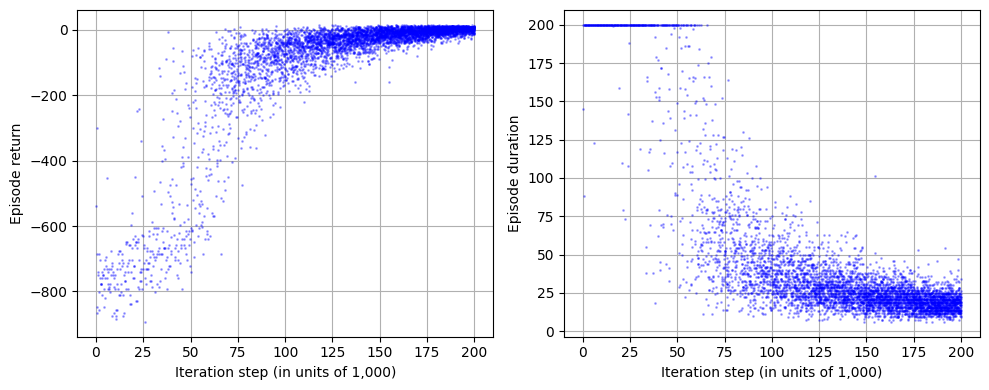

In [170]:
# # Make the list of steps more readable by removing zeroes.
# step_list = np.array(step_list, dtype=int) / 1000

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()
_ = [ax.grid(visible=True) for ax in axes]
axes[0].plot(step_list, return_list, 'bo', markersize=1, alpha=0.3)
axes[0].set_xlabel("Iteration step (in units of 1,000)")
axes[0].set_ylabel("Episode return")
axes[1].plot(step_list, duration_list, 'bo', markersize=1, alpha=0.3)
axes[1].set_xlabel("Iteration step (in units of 1,000)")
axes[1].set_ylabel("Episode duration")
plt.tight_layout()

## Results

The left subplot shows the total return of each episode during training, while the right subplot shows the number of steps in each episode. We see that initially (iterations 0-50), returns were in the high negatives and episode durations were mostly 200 (which is the maximum possible amount). This means very few tasks ended in successful dropoff of passengers (though we see that some did). As training progressed, more episodes ended quicker (which also means successfully). After 200,000 iterations, the expected return converges to roughly zero, and the average number of steps per episode is less than 25. 

It is possible that a better choice of $\alpha$ and $\epsilon$ would give us better results, but first I want to record the agent playing several episodes. This will allows us to see for ourselves how well it performs.

**Note:** I forgot to disable `is_rainy=True`. This setting causes the cab to go left or right of its intended direction 20% of the time. This will make the cab move in questionable directions some times.

In [192]:
from IPython.display import Video
import imageio

video_env    = gym.make("Taxi-v3", fickle_passenger=False, is_rainy=True, render_mode='rgb_array')
video_dir    = 'videos'
fps          = 2
agent.eps    = 0         # Disable random, exploratory action selection for the agent.

for i in range(10): # We'll record 10 episodes.
    state, _    = video_env.reset()
    frames_list = []
    done        = False
    
    # Play an episode.
    while not done:
        action = agent.choose_action(state)
        state, _, terminated, truncated, _ = video_env.step(action)
#         print(state)
        frame  = video_env.render()
        frames_list.append(frame)
        done = terminated or truncated
        
    # Repeat the last frame 'fps' times. My video app cuts to black instantly, so I can't see it otherwise.
    frames_list.extend([frame]*fps)
        
    # Save the video. Repeat the last frame a few times (my video app cuts to black immediately, so I miss it otherwise).
    imageio.mimsave(f'{video_dir}/taxi_{i}.mp4', frames_list, fps=fps, macro_block_size=1)

Below, I'll play some of the episodes.

In [193]:
Video("videos/taxi_0.mp4", embed=True)

We see the cab staying in place for several steps (we can confirm this by printing `state` in the loop above). This is not a behavior we expect. From the documentation for this Taxi environment, 

```For some cases, taking an action will have no effect on the state of the episode. In v0.25.0, info["action_mask"] contains a np.ndarray for each of the actions specifying if the action will change the state.```

In [195]:
Video("videos/taxi_5.mp4", embed=True)

In this video, we see the cab pick up a passenger then get stuck driving into a wall for the rest of the episode. This makes sense, since the policy is deterministic and once it gets stuck there's no way to get unstuck (unless we set $\eps > 0$ and hope to randomly move to a state that gets us unstuck). **This perhaps shows the danger of modeling a system as Markovian**; since each action is selected independently of previous actions and states, getting stuck like this is a real danger. A possible workaround would be to combine sequential states into "super-states", and use those as our MDP's states. However, that will slow down convergence considerably.

In [196]:
Video("videos/taxi_9.mp4", embed=True)

The cap appears to skip several tiles. I'm not sure if this is in fact happening, or if it is an artefact of my video rendering/embedding.

# Next steps

As mentioned previously, an interesting next step would be to do a hyperparameter search to find the best values for $\alpha$ and the best scheme for decreasing $\epsilon$ over the training. We could also set `ficke_passenger=True` to see what effect that has.